# Resultados das buscas locais — TSP

Este notebook lê `resultados_tsp.csv` e gera gráficos de barras para comparar o tempo médio e o custo médio encontrado pelas três buscas locais.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ARQUIVO_RESULTADOS = "./resultados/resultados_tsp.csv"

df = pd.read_csv(ARQUIVO_RESULTADOS)

df.head()

,quantidade_cidades,iteracao,execucao,algoritmo,seed,custo,tempo_ms,reaquecimentos
0,16,1,1,Hill Climbing,2096804712593481934,7876,0.9549,0
1,16,1,1,Simulated Annealing,2921580012919480942,7287,8.7908,0
2,16,1,1,SA com Reaquecimento,7354398262316660715,7271,10.5944,0
3,16,1,2,Hill Climbing,6237348419996972167,6838,2.9916,0
4,16,1,2,Simulated Annealing,3607348892368485766,7411,9.4135,0


C:\Users\Gawin\AppData\Local\Temp\ipykernel_24812\1194561119.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["quantidade_cidades", "algoritmo"])["tempo_ms"]


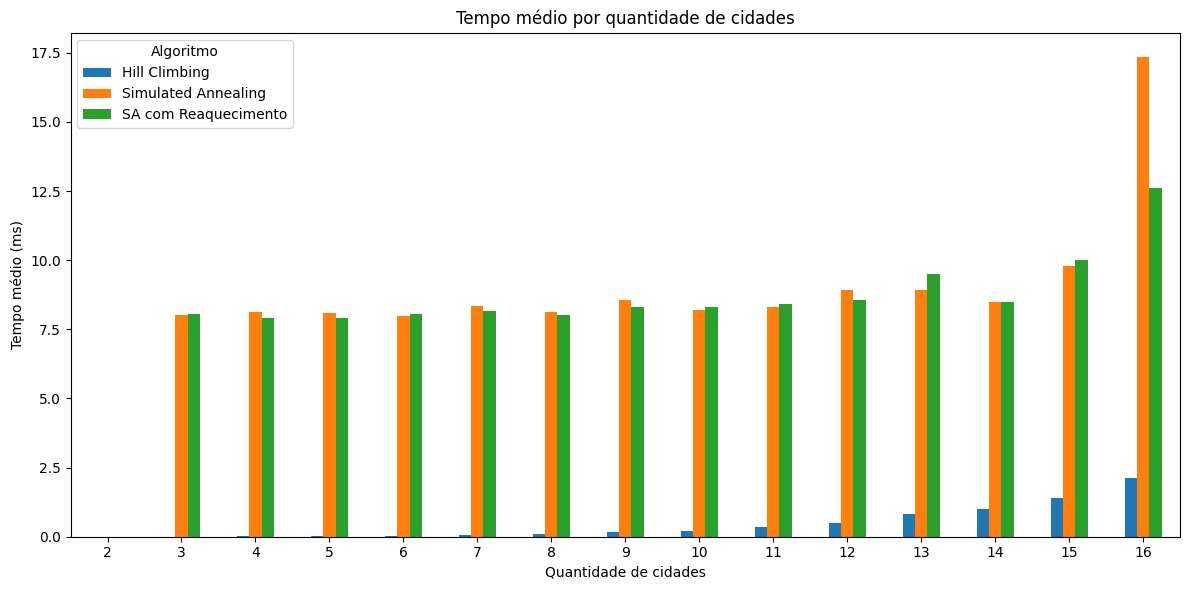

In [2]:

ordem_algoritmos = [
    "Hill Climbing",
    "Simulated Annealing",
    "SA com Reaquecimento"
]

df["algoritmo"] = pd.Categorical(
    df["algoritmo"],
    categories=ordem_algoritmos,
    ordered=True
)

# Calcula o tempo médio de cada algoritmo para cada quantidade de cidades
tempo_medio = (
    df.groupby(["quantidade_cidades", "algoritmo"])["tempo_ms"]
      .mean()
      .unstack()
)

ax = tempo_medio.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Tempo médio por quantidade de cidades")
ax.set_xlabel("Quantidade de cidades")
ax.set_ylabel("Tempo médio (ms)")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\Gawin\AppData\Local\Temp\ipykernel_24812\2617224846.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["quantidade_cidades", "algoritmo"])["custo"]


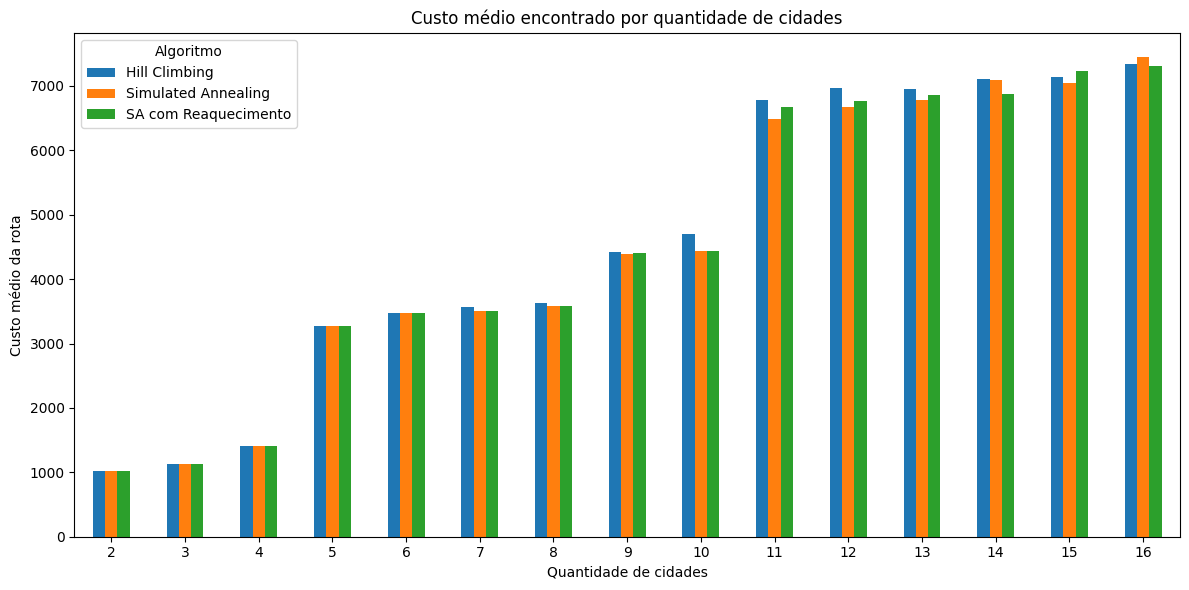

In [3]:

ordem_algoritmos = [
    "Hill Climbing",
    "Simulated Annealing",
    "SA com Reaquecimento"
]

df["algoritmo"] = pd.Categorical(
    df["algoritmo"],
    categories=ordem_algoritmos,
    ordered=True
)

# Calcula o custo médio encontrado por cada algoritmo
custo_medio = (
    df.groupby(["quantidade_cidades", "algoritmo"])["custo"]
      .mean()
      .unstack()
)

ax = custo_medio.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Custo médio encontrado por quantidade de cidades")
ax.set_xlabel("Quantidade de cidades")
ax.set_ylabel("Custo médio da rota")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()